In [1]:
import numpy as np
import os
import torch
import torchvision
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import random
from tqdm import tqdm
import time
from colorama import Fore
import matplotlib.pyplot as plt

random.seed(0)
torch.manual_seed(0)

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
prepare_imgs = torchvision.transforms.Compose(
    [
        torchvision.transforms.Resize((224, 224)), #приводим картинки к одному размеру
        torchvision.transforms.ToTensor(), # упаковывем их в тензор
        torchvision.transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] # нормализуем картинки по каналам
        ),
    ]
)

dataset = ImageFolder('data/flowers', transform=prepare_imgs)

In [4]:
class ValueMeter(object):
  def __init__(self):
      self.sum = 0
      self.total = 0

  def add(self, value, n):
      self.sum += value*n
      self.total += n

  def value(self):
      return self.sum/self.total

def log(mode, epoch, loss_meter: ValueMeter, accuracy_meter, best_perf=None):
  print(
      f"[{mode}] Epoch: {epoch:0.2f}. "
      f"Loss: {loss_meter.value():.2f}. "
      f"Accuracy: {100*accuracy_meter.value():.2f}% ", end="\n")

  if best_perf:
      print(f"[best: {best_perf:0.2f}]%", end="")

In [5]:
first_model = nn.Sequential(
            # in: 3 x 224 x 224
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 64 x 112 x 112

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 128 x 56 x 56

            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # output: 256 x 28 x 28

            nn.Flatten(),
            nn.Linear(256*28*28, 1024), 
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 5)
)
first_model.to(device)


Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU()
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU()
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (15): Flatten(start_dim=1, end_dim=-1)
  (16): Linear(in_features=200704, out_features=1024, bias=True)
  (17): ReLU()
  (18): Linear(in_features=1024, out_features=512, bias=True)
  (19): ReLU()
  (20): Lin

In [6]:
optimizer = torch.optim.Adam(params = first_model.parameters())
lr = 0.001

In [7]:
train_set, val_set = torch.utils.data.random_split(dataset, [len(dataset)-1000, 1000])

def create_loaders() -> dict[str, DataLoader]:
  batch_size = 32

  print('Размер обучающего и валидационного датасета: ', len(train_set), len(val_set))

  loaders = {
    'training': DataLoader(
      train_set, batch_size, pin_memory=True, num_workers=4, shuffle=True
    ),
    'validation':DataLoader(
      val_set, batch_size, pin_memory=True, num_workers=4, shuffle=False
    )
  }

  return loaders
  
loaders = create_loaders()

Размер обучающего и валидационного датасета:  3317 1000


In [8]:
def calc_accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

In [9]:
def trainval(model, loaders, optimizer, epochs=10):
    start_time = time.time()

    loss_meter = {'training': ValueMeter(), 'validation': ValueMeter()}
    accuracy_meter = {'training': ValueMeter(), 'validation': ValueMeter()}

    loss_track = {'training': [], 'validation': []}
    accuracy_track = {'training': [], 'validation': []}

    for epoch in range(epochs): # итерации по эпохам
        for mode in ['training', 'validation']: # обучение - валидация
            # считаем градиаент только при обучении:
            with torch.set_grad_enabled(mode == 'training'):
                
                # в зависимоти от фазы переводим модель в нужный ружим:
                if mode == 'training':
                    model.train() 
                else:
                    model.eval()
                    
                for imgs, labels in tqdm(loaders[mode]):
                    imgs = imgs.to(device) # отправляем тензор на GPU
                    labels = labels.to(device)
                    bs = labels.shape[0]  # размер батча (отличается для последнего батча в лоадере)

                    preds = model(imgs) # forward pass - прогоняем тензор с картинками через модель
                    loss = F.cross_entropy(preds, labels) # считаем функцию потерь
                    acc = calc_accuracy(preds, labels) # считаем метрику

                    # храним loss и accuracy для батча
                    loss_meter[mode].add(loss.item(), bs)
                    accuracy_meter[mode].add(acc, bs)

                    # если мы в фазе обучения
                    if mode == 'training':
                        optimizer.zero_grad() # обнуляем прошлый градиент
                        loss.backward() # делаем backward pass (считаем градиент)
                        optimizer.step() # обновляем веса
            # в конце фазы выводим значения loss и accuracy
            log(mode, epoch, loss_meter[mode], accuracy_meter[mode])

            # сохраняем результаты по всем эпохам
            loss_track[mode].append(loss_meter[mode].value())
            accuracy_track[mode].append(accuracy_meter[mode].value())

    print(f'{Fore.LIGHTMAGENTA_EX}Elapsed time = {time.time() - start_time}{Fore.RESET}')
    return loss_track, accuracy_track

In [10]:
first_loss_track, first_accuracy_track = trainval(first_model, loaders, optimizer, epochs=10)

100%|██████████| 104/104 [00:29<00:00,  3.57it/s]


[training] Epoch: 0.00. Loss: 1.41. Accuracy: 36.12% 


100%|██████████| 32/32 [00:02<00:00, 13.10it/s]


[validation] Epoch: 0.00. Loss: 1.34. Accuracy: 42.00% 


100%|██████████| 104/104 [00:28<00:00,  3.66it/s]


...

[validation] Epoch: 8.00. Loss: 1.61. Accuracy: 54.07% 


100%|██████████| 104/104 [00:28<00:00,  3.66it/s]


[training] Epoch: 9.00. Loss: 0.67. Accuracy: 72.75% 


100%|██████████| 32/32 [00:02<00:00, 13.20it/s]

[validation] Epoch: 9.00. Loss: 1.69. Accuracy: 54.39% 
Elapsed time = 309.0693278312683


In [11]:
from matplotlib import pyplot as plt

def plot_model(accuracy_track) -> None:
  plt.plot(accuracy_track['training'], label='training', color ='c')
  plt.plot(accuracy_track['validation'], label='validation', color='tomato', linestyle='--')
  plt.ylabel('accuracy')
  plt.xlabel('epoch')
  plt.grid()
  plt.legend()
  plt.show()

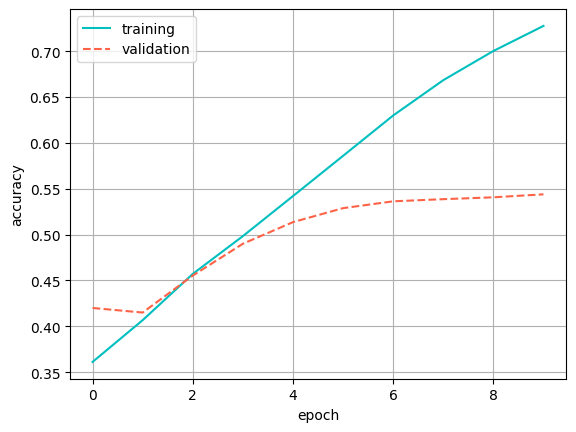

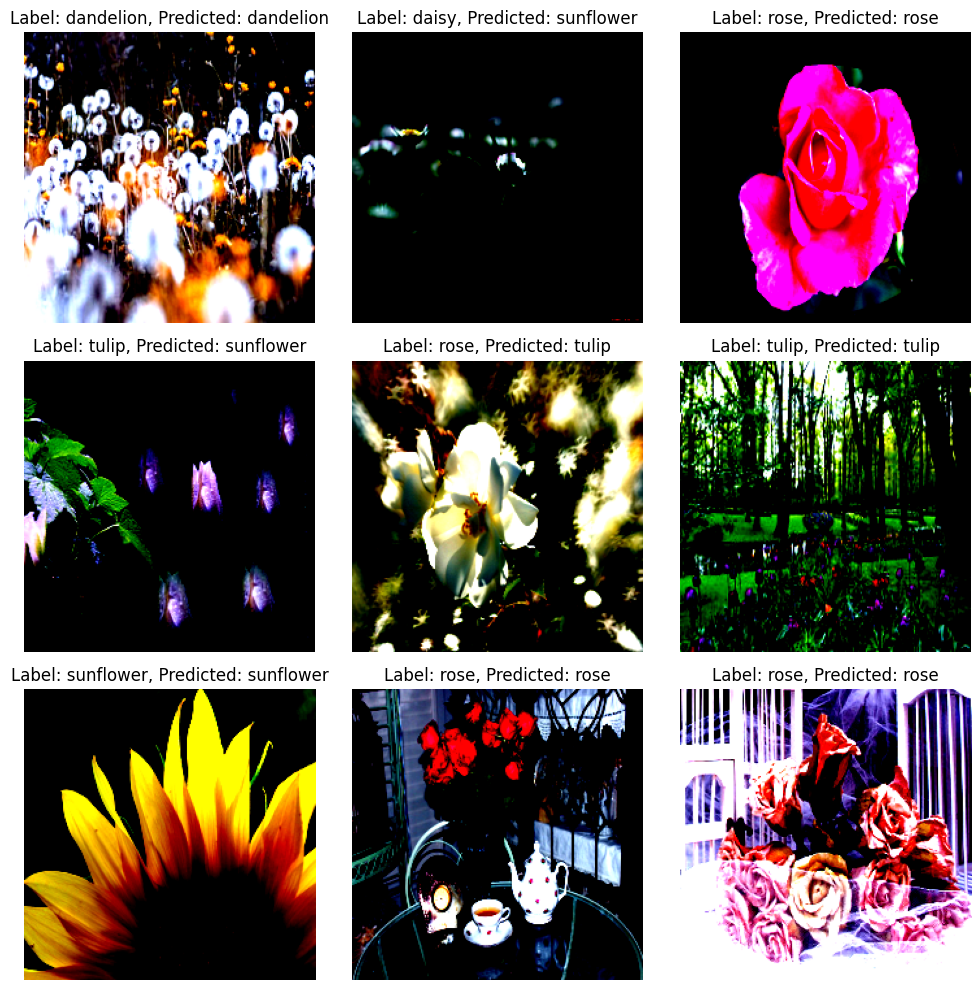

In [71]:
def predict_image(img, model):
    # Преобразование to a batch of 1
    xb = img.unsqueeze(0).to(device)
    # Получение прогнозов от модели
    yb = model(xb)
    # Выбираем индекс с наибольшей вероятностью
    _, preds  = torch.max(yb, dim=1)
    # Получение метки класса
    return dataset.classes[preds[0].item()]


def demonstrate_predictions(model, accuracy_track):
  plot_model(accuracy_track)
  plt.figure(figsize=(10, 10))

  for i in range(1,10):
    plt.subplot(3, 3, i)
    img, label = val_set[-i]
    plt.imshow(img.clip(0,1).permute(1, 2, 0))
    plt.axis('off')
    plt.title(f'Label: {dataset.classes[label]}, Predicted: {predict_image(img, model)}')

  plt.tight_layout()
  plt.show()
  
demonstrate_predictions(first_model, first_accuracy_track)

In [98]:
classification_models = torchvision.models.list_models(module=torchvision.models)

print(classification_models)

torch_model = torchvision.models.resnet50(pretrained=True)

print(torch_model)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

In [99]:
def set_parameter_requires_grad(model):
  for param in model.parameters():
    param.requires_grad = False

set_parameter_requires_grad(torch_model)

In [102]:
num_features = torch_model.fc.in_features
torch_model.fc = torch.nn.Linear(in_features=num_features, out_features=len(dataset.classes), bias=True)

In [103]:
def print_retraining_layers(model):
  for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'{Fore.RED}{name}{Fore.RESET}')
    else:
        print(f'{Fore.GREEN}{name}{Fore.RESET}')
       

print_retraining_layers(torch_model)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.0.conv3.weight
layer1.0.bn3.weight
layer1.0.bn3.bias
layer1.0.downsample.0.weight
layer1.0.downsample.1.weight
layer1.0.downsample.1.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.1.conv3.weight
layer1.1.bn3.weight
layer1.1.bn3.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer1.2.conv3.weight
layer1.2.bn3.weight
layer1.2.bn3.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.conv3.weight
layer2.0.bn3.weight
layer2.0.bn3.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.we

In [104]:
random.seed(0)
torch.manual_seed(0)

torch_model.to(device)
optimizer = torch.optim.Adam(params = torch_model.parameters())
torch_loss_track, torch_accuracy_track = trainval(torch_model, loaders, optimizer, epochs=10)

100%|██████████| 104/104 [00:07<00:00, 14.51it/s]


[training] Epoch: 0.00. Loss: 0.70. Accuracy: 76.39% 


100%|██████████| 32/32 [00:02<00:00, 14.18it/s]


[validation] Epoch: 0.00. Loss: 0.42. Accuracy: 85.80% 


100%|██████████| 104/104 [00:07<00:00, 14.46it/s]


...

[validation] Epoch: 8.00. Loss: 0.33. Accuracy: 89.06% 


100%|██████████| 104/104 [00:07<00:00, 14.36it/s]


[training] Epoch: 9.00. Loss: 0.34. Accuracy: 88.38% 


100%|██████████| 32/32 [00:02<00:00, 14.15it/s]

[validation] Epoch: 9.00. Loss: 0.33. Accuracy: 89.14% 
Elapsed time = 95.12142324447632


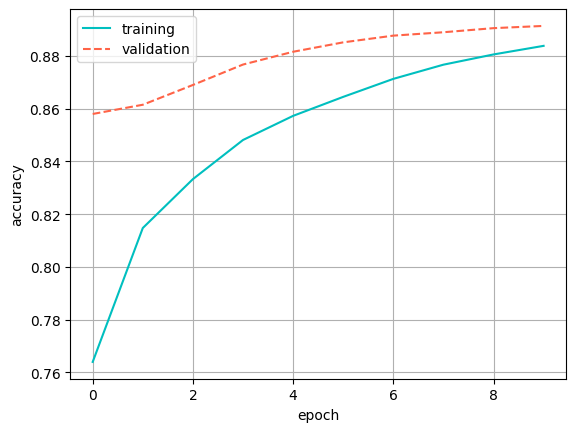

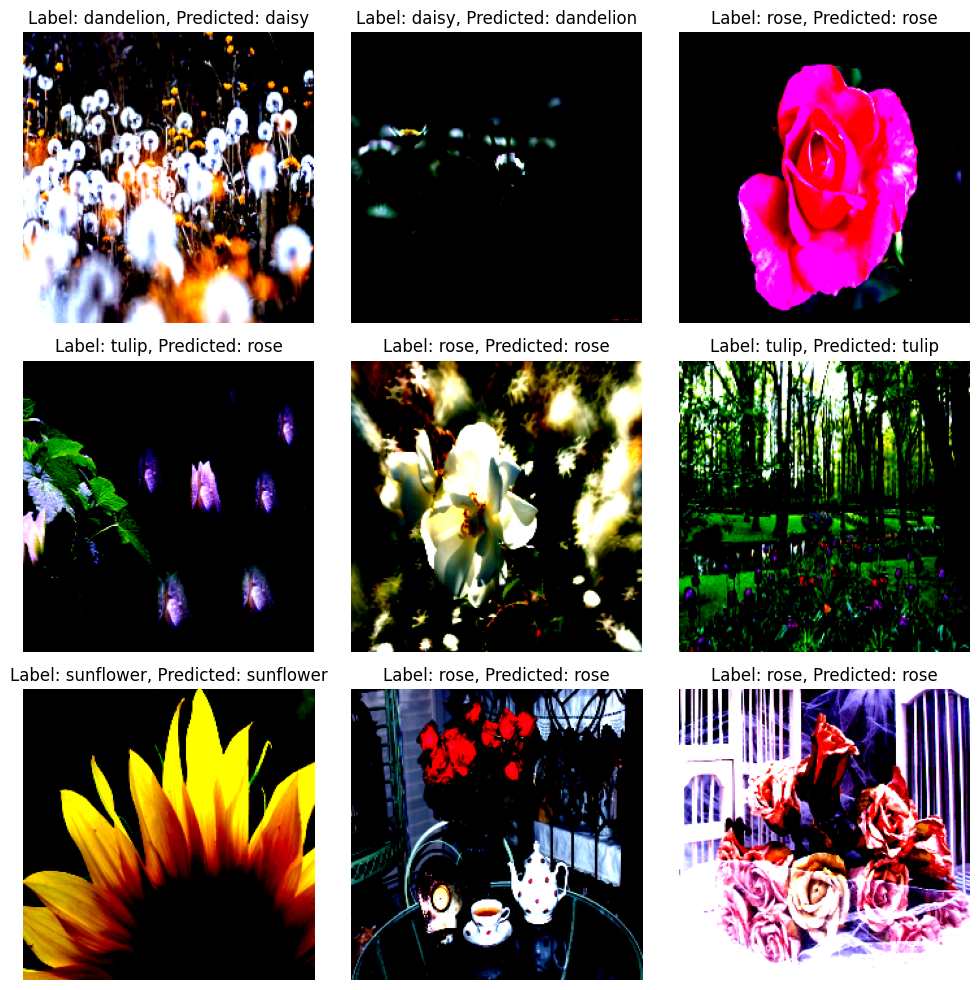

In [105]:
demonstrate_predictions(torch_model, torch_accuracy_track)